import libraries

In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

load dataset

In [232]:
sales = pd.read_csv("restaurant_sales.csv", parse_dates=["date"])
weather = pd.read_csv("Daily_Weather_Insights.csv", parse_dates=["Date"])
holidays = pd.read_csv("Global_Holidays_2025_2035.csv", parse_dates=["Date"])

/tmp/ipykernel_5898/2494791094.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  holidays = pd.read_csv("Global_Holidays_2025_2035.csv", parse_dates=["Date"])


In [233]:
weather.rename(columns={"Date":"date"}, inplace=True)
holidays.rename(columns={"Date":"date"}, inplace=True)

In [234]:
print(sales.head(5))

        date   sales
0 2025-01-01  281.64
1 2025-01-02  212.74
2 2025-01-03  250.61
3 2025-01-04  253.38
4 2025-01-05  253.00


In [235]:
sales.index=sales['date']

In [236]:
print(sales.head(5))

                 date   sales
date                         
2025-01-01 2025-01-01  281.64
2025-01-02 2025-01-02  212.74
2025-01-03 2025-01-03  250.61
2025-01-04 2025-01-04  253.38
2025-01-05 2025-01-05  253.00


In [237]:
del sales['date']

In [238]:
print(sales.head(5))

             sales
date              
2025-01-01  281.64
2025-01-02  212.74
2025-01-03  250.61
2025-01-04  253.38
2025-01-05  253.00


In [239]:
sales.isnull().sum().sum()

np.int64(0)

In [240]:
sales.duplicated().sum()

np.int64(6)

In [241]:
sales.drop_duplicates(inplace=True)

In [242]:
sales.duplicated().sum()

np.int64(0)

In [243]:
print(weather.head(5))

        date   City  Temperature_High (°C)  Temperature_Low (°C)  \
0 2025-01-01  Cairo                   16.9                  14.1   
1 2025-01-02  Cairo                   15.1                   5.6   
2 2025-01-03  Cairo                   25.1                  18.2   
3 2025-01-04  Cairo                   28.9                   9.9   
4 2025-01-05  Cairo                   17.6                  13.7   

   Humidity (%)  Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
0          43.1               24.2             Sunny                145   
1          56.9                8.2             Windy                115   
2          52.5               18.2             Snowy                 11   
3          76.3               18.8             Rainy                 22   
4          55.6               10.8             Sunny                 39   

   Precipitation (mm)  Visibility (km)  
0                17.2              4.7  
1                 0.5              9.8  
2                

In [244]:
weather.index=weather['date']

In [245]:
del weather['date']

In [246]:
print(weather.head(5))

             City  Temperature_High (°C)  Temperature_Low (°C)  Humidity (%)  \
date                                                                           
2025-01-01  Cairo                   16.9                  14.1          43.1   
2025-01-02  Cairo                   15.1                   5.6          56.9   
2025-01-03  Cairo                   25.1                  18.2          52.5   
2025-01-04  Cairo                   28.9                   9.9          76.3   
2025-01-05  Cairo                   17.6                  13.7          55.6   

            Wind_Speed (km/h) Weather_Condition  Air_Quality_Index  \
date                                                                 
2025-01-01               24.2             Sunny                145   
2025-01-02                8.2             Windy                115   
2025-01-03               18.2             Snowy                 11   
2025-01-04               18.8             Rainy                 22   
2025-01-05         

In [247]:
weather.isnull().sum().sum()

np.int64(0)

In [248]:
weather.duplicated().sum()

np.int64(0)

In [249]:
print(weather.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90 entries, 2025-01-01 to 2025-03-31
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   City                   90 non-null     object 
 1   Temperature_High (°C)  90 non-null     float64
 2   Temperature_Low (°C)   90 non-null     float64
 3   Humidity (%)           90 non-null     float64
 4   Wind_Speed (km/h)      90 non-null     float64
 5   Weather_Condition      90 non-null     object 
 6   Air_Quality_Index      90 non-null     int64  
 7   Precipitation (mm)     90 non-null     float64
 8   Visibility (km)        90 non-null     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 7.0+ KB
None


In [250]:
print(holidays.head(5))

  Country  Year                 date               Holiday_Name  Local_Name  \
0      IN  2025  2025-01-01 00:00:00             New Year's Day         NaN   
1      IN  2025  2025-02-01 00:00:00       Last day of Hanukkah         NaN   
2      IN  2025  2025-06-01 00:00:00  Guru Govind Singh Jayanti         NaN   
3      IN  2025  2025-01-13 00:00:00                      Lohri         NaN   
4      IN  2025  2025-01-14 00:00:00                     Pongal         NaN   

                         Type  
0            Optional holiday  
1                  Observance  
2            Optional holiday  
3                  Observance  
4  Hinduism, Optional holiday  


In [251]:
holidays['date'] = pd.to_datetime(holidays['date'], format='%Y-%m-%d', errors='coerce')

In [252]:
holidays = holidays[holidays['date'].between('2025-01-01','2028-12-31')]

In [253]:
holidays.index=holidays['date']

In [254]:
del holidays['date']
del holidays['Local_Name']


In [255]:
del holidays['Year']

In [256]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19 entries, 2025-01-01 to 2025-03-14
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country       19 non-null     object
 1   Holiday_Name  19 non-null     object
 2   Type          19 non-null     object
dtypes: object(3)
memory usage: 608.0+ bytes


In [257]:
holidays.isnull().sum().sum()

np.int64(0)

In [258]:
holidays.duplicated().sum()

np.int64(0)

In [259]:
holidays.shape

(19, 3)

In [260]:
# Merge sales with weather and holidays
df = sales.merge(weather, on="date", how="left")
df = df.merge(holidays, on="date", how="left")



In [261]:
df.head(5)

,sales,City,Temperature_High (°C),Temperature_Low (°C),Humidity (%),Wind_Speed (km/h),Weather_Condition,Air_Quality_Index,Precipitation (mm),Visibility (km),Country,Holiday_Name,Type
date,,,,,,,,,,,,,
2025-01-01,281.64,Cairo,16.9,14.1,43.1,24.2,Sunny,145.0,17.2,4.7,IN,New Year's Day,Optional holiday
2025-01-02,212.74,Cairo,15.1,5.6,56.9,8.2,Windy,115.0,0.5,9.8,NaN,NaN,NaN
2025-01-03,250.61,Cairo,25.1,18.2,52.5,18.2,Snowy,11.0,6.0,2.5,NaN,NaN,NaN
2025-01-04,253.38,Cairo,28.9,9.9,76.3,18.8,Rainy,22.0,6.8,9.4,NaN,NaN,NaN
2025-01-05,253.00,Cairo,17.6,13.7,55.6,10.8,Sunny,39.0,12.6,4.5,NaN,NaN,NaN


In [262]:
df['Country'].unique()

array(['IN', nan], dtype=object)

In [263]:
df['Country'] = df['Country'].fillna('IN')
df['Holiday_Name'] = df['Holiday_Name'].fillna('No Holiday')
df['Type'] = df['Type'].fillna('No Type')

In [264]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(0)
print(df.isnull().sum().sum())

540


In [265]:
df.dropna(inplace=True)

In [266]:
df = df.sort_values(by='date')

In [267]:
print(df.columns)

Index(['sales', 'City', 'Temperature_High (°C)', 'Temperature_Low (°C)',
       'Humidity (%)', 'Wind_Speed (km/h)', 'Weather_Condition',
       'Air_Quality_Index', 'Precipitation (mm)', 'Visibility (km)', 'Country',
       'Holiday_Name', 'Type'],
      dtype='object')


In [268]:
df.describe()


,sales,Temperature_High (°C),Temperature_Low (°C),Humidity (%),Wind_Speed (km/h),Air_Quality_Index,Precipitation (mm),Visibility (km)
count,92.000000,92.000000,92.00000,92.000000,92.000000,92.000000,92.000000,92.000000
mean,233.472826,25.671739,12.77500,52.538043,14.321739,105.304348,9.366304,5.742391
std,37.688308,5.709974,4.15937,14.976933,5.708733,55.211629,5.984693,2.405133
min,176.270000,15.100000,5.20000,30.300000,5.100000,11.000000,0.400000,2.300000
25%,202.390000,20.450000,9.10000,39.425000,9.925000,61.000000,4.450000,3.500000
50%,223.000000,26.800000,12.55000,49.350000,14.000000,111.500000,8.000000,5.350000
75%,260.550000,29.975000,16.22500,63.625000,19.000000,154.000000,14.925000,7.525000
max,385.600000,34.900000,19.80000,78.100000,24.400000,200.000000,19.300000,10.000000


In [269]:
def detect_outliers_iqr(df):
    outlier_dict = {}
    for col in df.select_dtypes(include=['float64','int64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        outlier_dict[col] = outliers
    return outlier_dict

# Example usage:
outliers = detect_outliers_iqr(df)
for col, vals in outliers.items():
    print(f"Column: {col}, Outliers count: {len(vals)}")
    print(vals.values[:10])  # show first 10 outlier values


Column: sales, Outliers count: 1
[385.6]
Column: Temperature_High (°C), Outliers count: 0
[]
Column: Temperature_Low (°C), Outliers count: 0
[]
Column: Humidity (%), Outliers count: 0
[]
Column: Wind_Speed (km/h), Outliers count: 0
[]
Column: Air_Quality_Index, Outliers count: 0
[]
Column: Precipitation (mm), Outliers count: 0
[]
Column: Visibility (km), Outliers count: 0
[]


In [270]:
def handle_outliers(df, method="flag", action="keep"):
    """
    Detects outliers in all numeric columns using IQR.
    Parameters:
        df (DataFrame): your dataset
        method (str): 'iqr' (default) or 'zscore'
        action (str): 'keep', 'remove', or 'cap'
    Returns:
        DataFrame with outliers handled according to action
    """
    df_out = df.copy()
    numeric_cols = df_out.select_dtypes(include=['float64','int64']).columns

    for col in numeric_cols:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q

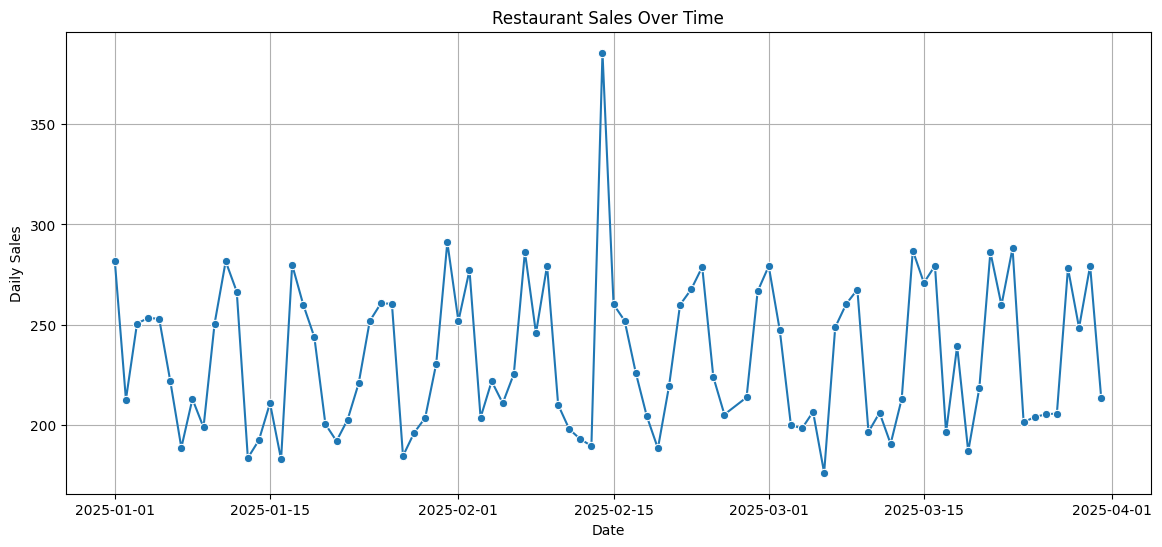

In [271]:
plt.figure(figsize=(14,6))
sns.lineplot(x='date', y='sales', data=df, marker='o')

plt.title("Restaurant Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.grid(True)
plt.show()

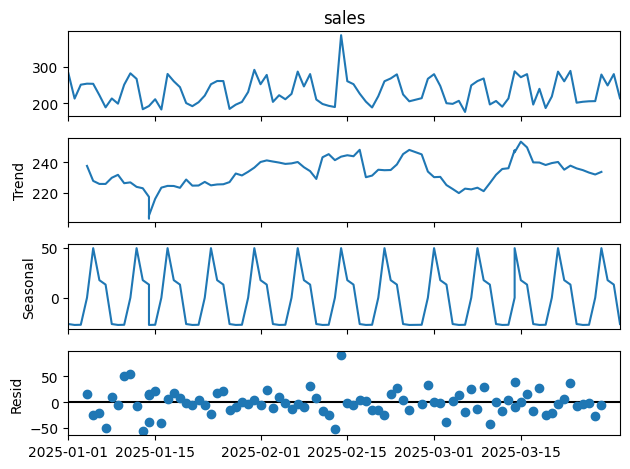

In [272]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Assume sales is your target column
result = seasonal_decompose(df['sales'], model='additive', period=7)  # weekly seasonality
result.plot()
plt.show()

<Figure size 1200x400 with 0 Axes>

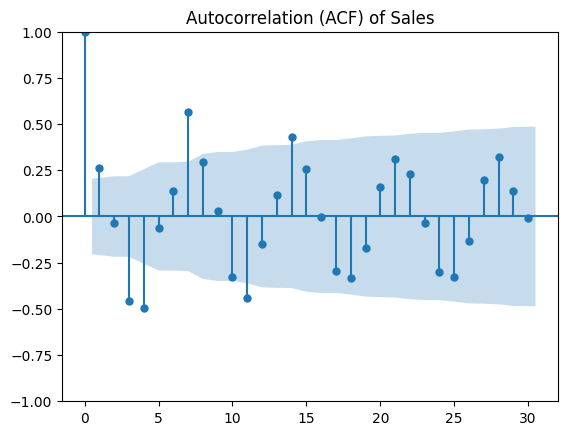

<Figure size 1200x400 with 0 Axes>

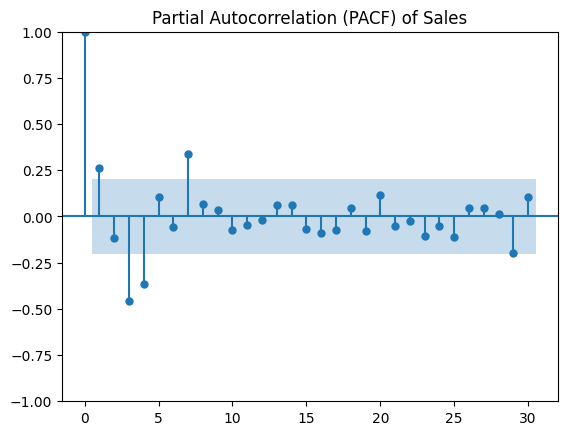

In [273]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF (autocorrelation function)
plt.figure(figsize=(12,4))
plot_acf(df['sales'].dropna(), lags=30)  # up to 30 lags
plt.title("Autocorrelation (ACF) of Sales")
plt.show()

# Plot PACF (partial autocorrelation function)
plt.figure(figsize=(12,4))
plot_pacf(df['sales'].dropna(), lags=30)
plt.title("Partial Autocorrelation (PACF) of Sales")
plt.show()


In [274]:
#Feature engineering

In [309]:
# Create lag features for sales
df['lag1'] = df['sales'].shift(1)   # previous day
df['lag7'] = df['sales'].shift(7)   # same day last week
df['lag30'] = df['sales'].shift(30) # same day last month

# Impute NA values introduced by shifting to retain data
df = df.infer_objects(copy=False) # Infer object dtypes before interpolating
df = df.interpolate(method='linear', limit_direction='both')
df = df.ffill()
df = df.bfill()

/tmp/ipykernel_5898/4012641848.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear', limit_direction='both')


In [310]:
# Rolling averages for sales
df['sales_roll3'] = df['sales'].rolling(window=3).mean()   # 3-day average
df['sales_roll7'] = df['sales'].rolling(window=7).mean()   # 7-day average (weekly)
df['sales_roll30'] = df['sales'].rolling(window=30).mean() # 30-day average (monthly)

# Impute NA values introduced by rolling windows to retain data
df = df.infer_objects(copy=False) # Infer object dtypes before interpolating
df = df.interpolate(method='linear', limit_direction='both')
df = df.ffill()
df = df.bfill()

/tmp/ipykernel_5898/2444724358.py:8: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='linear', limit_direction='both')


In [311]:
# This cell is removed as its functionality is now covered and improved in previous cells.

In [278]:
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar

# Example: US holidays (replace with your country’s calendar if needed)
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df.index.min(), end=df.index.max())

# Create a 'date' column from the index for easier manipulation
df['date'] = df.index
df['is_holiday'] = df['date'].isin(holidays).astype(int)
del df['date'] # delete the temporary 'date' column after use

In [279]:
# Flag weekends (Saturday=5, Sunday=6)
df['is_weekend'] = df.index.weekday.isin([5,6]).astype(int)

1 → weekend

0 → weekday

In [280]:
from statsmodels.tsa.stattools import adfuller

# Run ADF test on sales column
result = adfuller(df['sales'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])


ADF Statistic: -2.9239959135534312
p-value: 0.04262791187225401
Critical Values: {'1%': np.float64(-3.6889256286443146), '5%': np.float64(-2.9719894897959187), '10%': np.float64(-2.6252957653061224)}


p-value < 0.05 → reject null hypothesis → series is stationary.

p-value ≥ 0.05 → fail to reject null → series is non-stationary (needs

In [281]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Example categorical feature: day of week
df['day_of_week'] = df.index.day_name() # Use df.index instead of df['date']

# Initialize label encoder
le = LabelEncoder()

# Fit and transform
df['day_of_week_encoded'] = le.fit_transform(df['day_of_week'])

# Check mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Encoding Mapping:", mapping)

Label Encoding Mapping: {'Friday': np.int64(0), 'Monday': np.int64(1), 'Saturday': np.int64(2), 'Sunday': np.int64(3), 'Thursday': np.int64(4), 'Tuesday': np.int64(5), 'Wednesday': np.int64(6)}


In [282]:
# One-hot encode remaining categorical features
categorical_cols_to_encode = ['City', 'Weather_Condition', 'Country', 'Holiday_Name', 'Type']
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

# Display the first few rows and column names to confirm changes
print(df.head())
print(df.columns)

             sales  Temperature_High (°C)  Temperature_Low (°C)  Humidity (%)  \
date                                                                            
2025-02-28  266.68                   21.9                  12.9          50.7   
2025-03-01  279.25                   23.2                  10.8          69.2   
2025-03-02  247.19                   20.8                  17.3          61.3   
2025-03-03  200.08                   28.1                   8.7          47.5   
2025-03-04  198.33                   28.2                   7.5          39.7   

            Wind_Speed (km/h)  Air_Quality_Index  Precipitation (mm)  \
date                                                                   
2025-02-28               14.8              116.0                 5.4   
2025-03-01               16.3               39.0                19.3   
2025-03-02               16.8              168.0                19.3   
2025-03-03               21.2               26.0                18.7   


### Re-running Classical Models with Improved Imputation

model selection

In [283]:
#classical statistical model

In [314]:
# Train-test split (last 20% as test)
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

y_train, y_test = train['sales'], test['sales']


In [315]:
 #--- 1. ARIMA ---
arima_model = ARIMA(y_train, order=(0,0,0))   # Changed order to (0,0,0) as y_train is too small for (2,1,2)
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(y_test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [316]:
 #--- 2. SARIMA ---
sarima_model = SARIMAX(y_train, order=(2,1,2), seasonal_order=(1,1,1,7))  # weekly seasonality
sarima_fit = sarima_model.fit()
sarima_pred = sarima_fit.forecast(steps=len(y_test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  retu

In [317]:
# --- 3. Holt-Winters ---
hw_model = ExponentialSmoothing(y_train, trend='add') # Removed seasonal components due to insufficient data
hw_fit = hw_model.fit()
hw_pred = hw_fit.forecast(len(y_test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [318]:
# --- Evaluation with RMSE AND MAE ---
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{model_name} → RMSE: {rmse:.2f}, MAE: {mae:.2f}")
    return {"model_name": model_name, "rmse": rmse, "mae": mae}


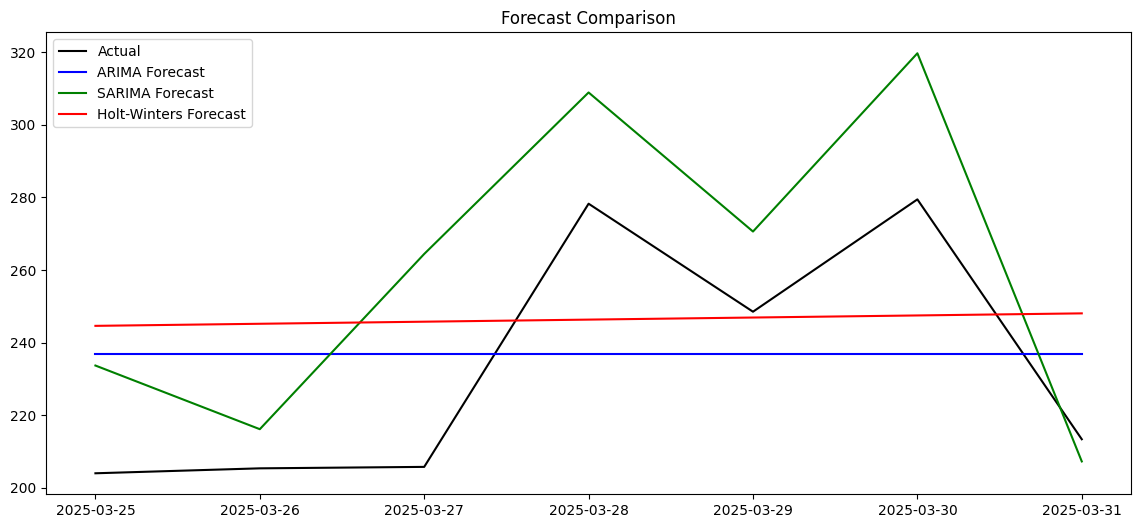

In [319]:
# --- Plot comparison ---
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label="Actual", color="black")
plt.plot(y_test.index, arima_pred[:len(y_test)], label="ARIMA Forecast", color="blue")
plt.plot(y_test.index, sarima_pred[:len(y_test)], label="SARIMA Forecast", color="green")
plt.plot(y_test.index, hw_pred[:len(y_test)], label="Holt-Winters Forecast", color="red")
plt.title("Forecast Comparison")
plt.legend()
plt.show()

Prophet → RMSE: 8.13, MAE: 6.76


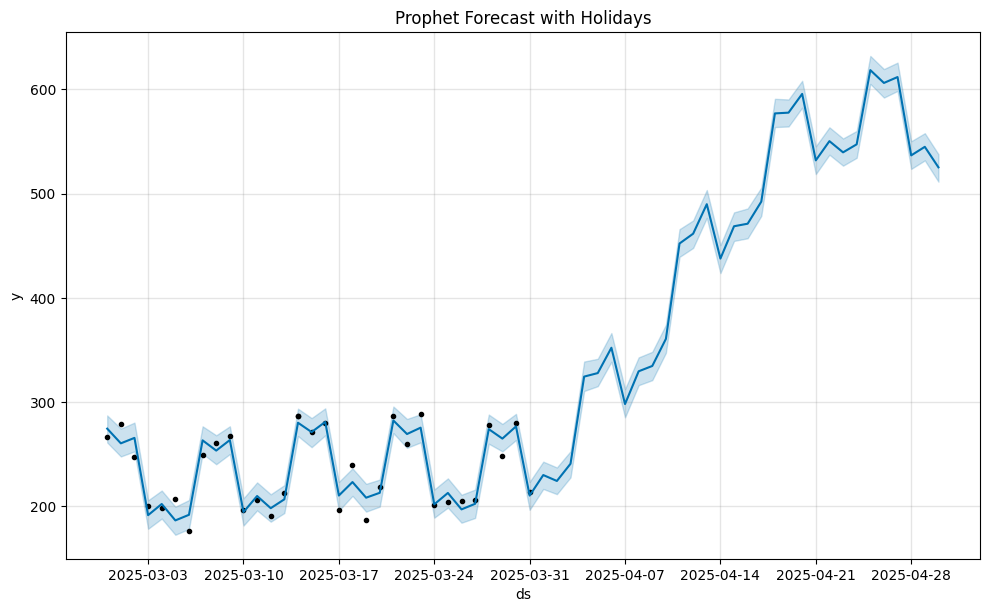

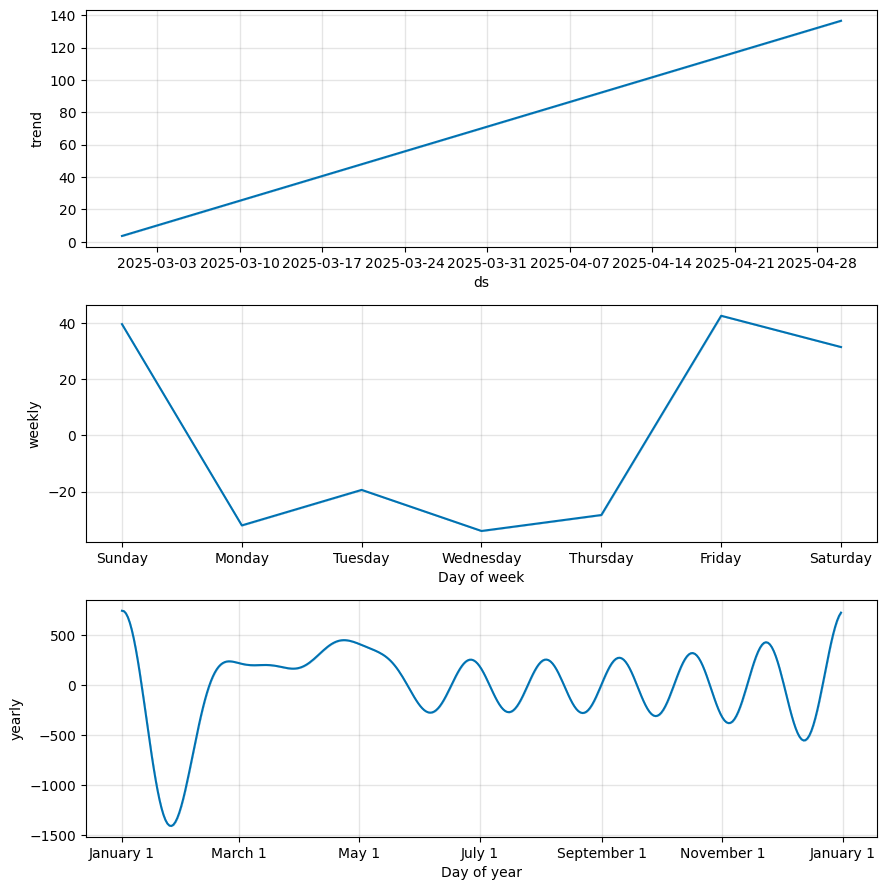

In [320]:
#modern models
# Add holiday effects (example: US holidays)
from pandas.tseries.holiday import USFederalHolidayCalendar
cal = USFederalHolidayCalendar()
holidays = pd.DataFrame({
    'holiday': 'USFederalHoliday',
    'ds': cal.holidays(start=df_prophet['ds'].min(), end=df_prophet['ds'].max()),
    'lower_window': 0,
    'upper_window': 1,
})

# Initialize Prophet model with all desired parameters and holidays
m = Prophet(
    yearly_seasonality=True,   # yearly patterns
    weekly_seasonality=True,   # weekly patterns
    daily_seasonality=False,   # set True if you have hourly data
    holidays=holidays
)

# Fit the model
m.fit(df_prophet)

# Make future dataframe (forecast horizon = 30 days)
future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)

# Evaluate on test set (last 20%)
train_size = int(len(df_prophet) * 0.8)
y_test = df_prophet['y'].iloc[train_size:]

# Get the dates from the test set of df_prophet to align predictions
test_ds_dates = df_prophet.iloc[train_size:]['ds']
y_pred = forecast[forecast['ds'].isin(test_ds_dates)]['yhat']

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"Prophet → RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# Plot forecast
fig1 = m.plot(forecast)
plt.title("Prophet Forecast with Holidays")
plt.show()

# Plot components (trend, weekly, yearly, holidays)
fig2 = m.plot_components(forecast)
plt.show()


### Visualize Prophet Model Performance

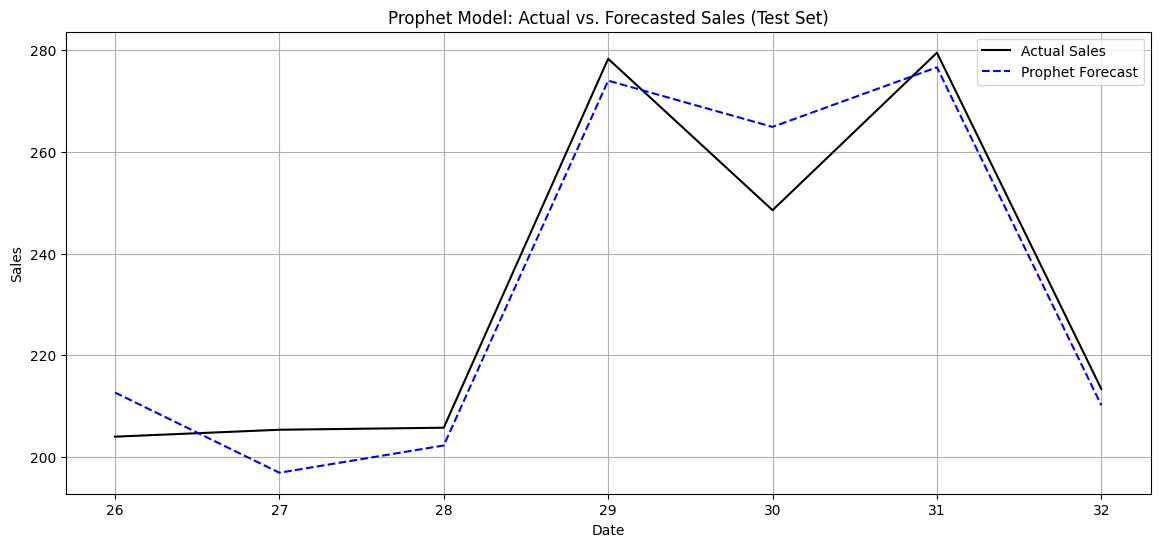

In [321]:
# Plot the actual values vs. Prophet forecast for the test set
plt.figure(figsize=(14, 6))
plt.plot(y_test_prophet.index, y_test_prophet, label='Actual Sales', color='black')
plt.plot(y_test_prophet.index, y_pred_prophet, label='Prophet Forecast', color='blue', linestyle='--')
plt.title('Prophet Model: Actual vs. Forecasted Sales (Test Set)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()


In [322]:
residuals_prophet = y_test_prophet - y_pred_prophet

In [323]:
residuals_prophet.head()

,0
25,NaN
26,7.080959
27,3.089812
28,-68.175693
29,13.380124


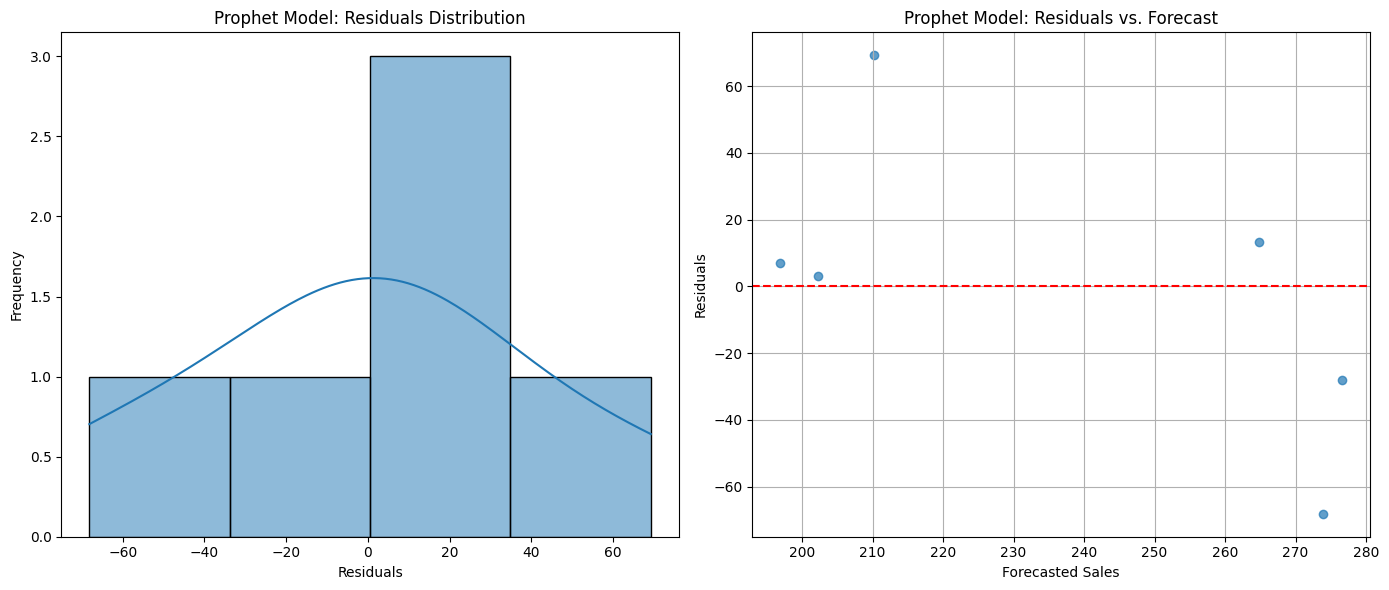

In [324]:
# Ensure y_test_prophet and y_pred_prophet are aligned by index
common_index = y_test_prophet.index.intersection(y_pred_prophet.index)

y_test_aligned = y_test_prophet.loc[common_index]
y_pred_aligned = y_pred_prophet.loc[common_index]

# Calculate residuals with aligned series
residuals_prophet = y_test_aligned - y_pred_aligned

# Visualize residuals
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(residuals_prophet, kde=True)
plt.title('Prophet Model: Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.scatter(y_pred_aligned, residuals_prophet, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Prophet Model: Residuals vs. Forecast')
plt.xlabel('Forecasted Sales')
plt.ylabel('Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

In [325]:
import joblib

# Save the Prophet model
joblib.dump(m, 'prophet_model.joblib')
print("Prophet model saved to prophet_model.joblib")

Prophet model saved to prophet_model.joblib


In [297]:
# Prepare data for XGBoost
# Features are all columns except 'sales' and 'day_of_week' (since we have 'day_of_week_encoded')
features = [col for col in df.columns if col not in ['sales', 'day_of_week']]
X = df[features]
y = df['sales']

# Split data using TimeSeriesSplit to maintain temporal order
tscv = TimeSeriesSplit(n_splits=2) # Using a small split for demonstration, adjust as needed
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (22, 25)
X_test shape: (11, 25)
y_train shape: (22,)
y_test shape: (11,)


In [300]:
# Initialize and train the XGBoost Regressor
# Using parameters known to work well from previous runs or default for a quick start
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_pred = xgb_model.predict(X_test)

# Evaluate the model
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae_xgb = mean_absolute_error(y_test, xgb_pred)

print(f"XGBoost → RMSE: {rmse_xgb:.2f}, MAE: {mae_xgb:.2f}")

XGBoost → RMSE: 27.08, MAE: 20.54


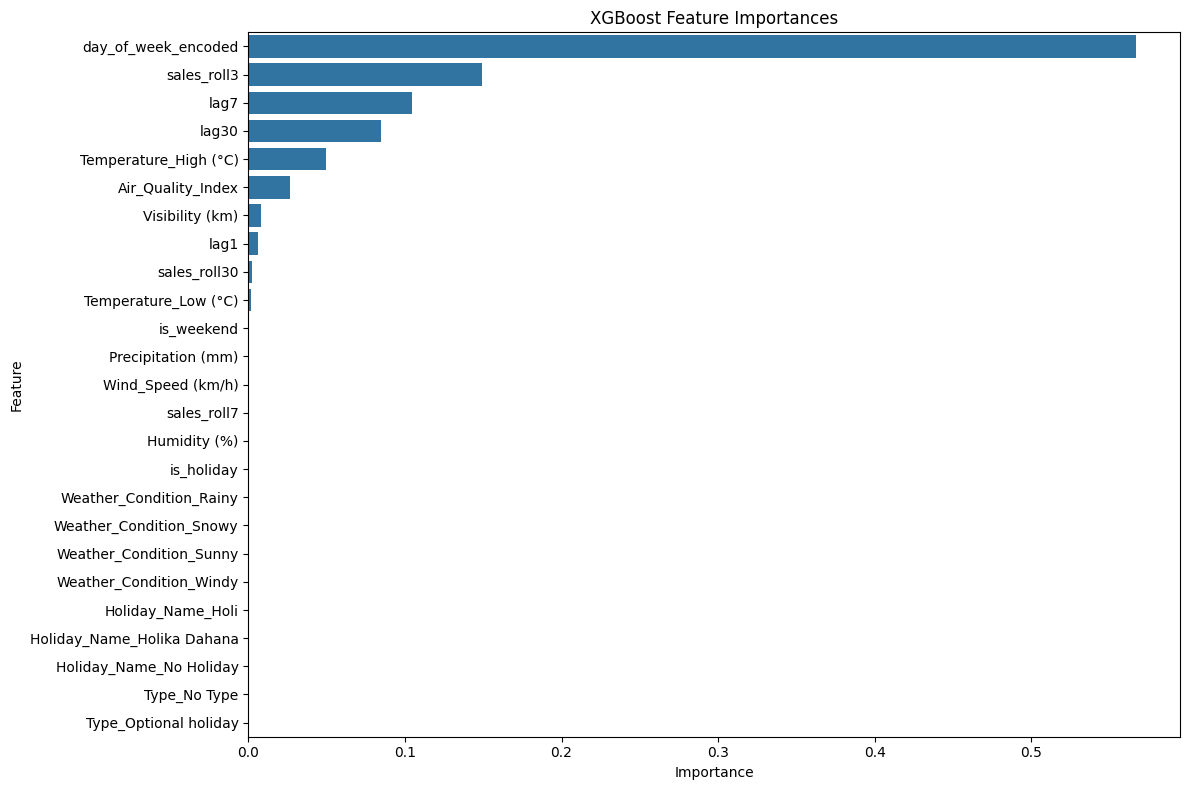

In [332]:
# Visualize Feature Importances
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

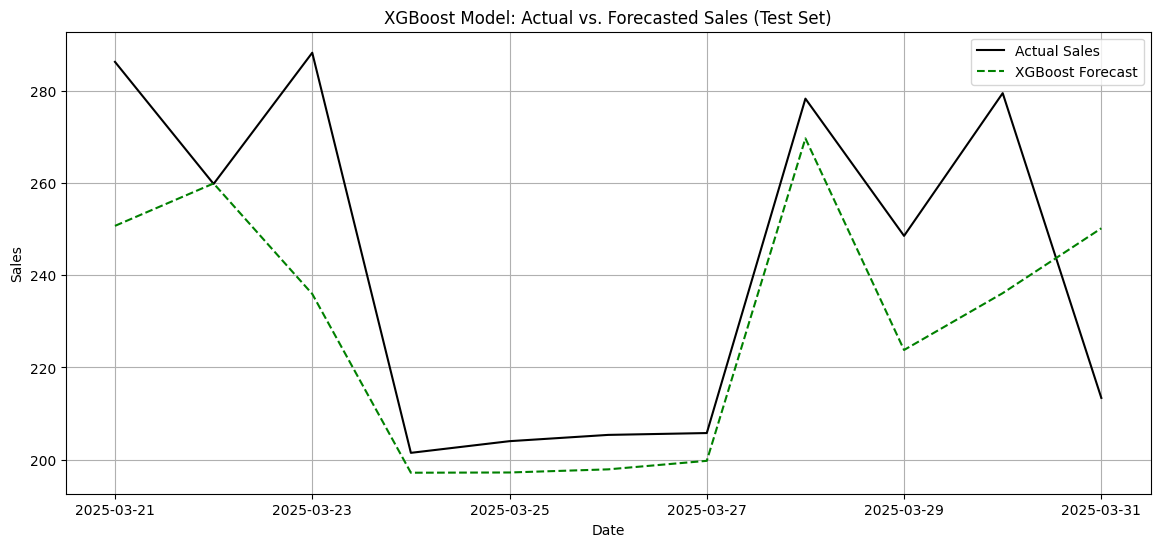

In [303]:
y_pred_xgb_series = pd.Series(xgb_pred, index=y_test.index)

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Actual Sales', color='black')
plt.plot(y_test.index, y_pred_xgb_series, label='XGBoost Forecast', color='green', linestyle='--')
plt.title('XGBoost Model: Actual vs. Forecasted Sales (Test Set)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

Hyperparameter Tuning (Random Forest) with Time-Series Cross-Validation

In [330]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize TimeSeriesSplit for internal GridSearchCV cross-validation
tscv_gs = TimeSeriesSplit(n_splits=3)  # Adjust n_splits based on data size and desired rigor

# Initialize GridSearchCV with RandomForestRegressor
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv_gs,  # Use tscv_gs for GridSearchCV's internal cross-validation
    scoring='neg_root_mean_squared_error',  # Optimize for RMSE
    n_jobs=-1,  # Use all available cores
    verbose=1
)

features = [col for col in df.columns if col not in ['sales', 'day_of_week']]
X_ml = df[features]
y_ml = df['sales']

tscv_split = TimeSeriesSplit(n_splits=2)
for train_index, test_index in tscv_split.split(X_ml):
    X_train_rf, X_test_rf = X_ml.iloc[train_index], X_ml.iloc[test_index]
    y_train_rf, y_test_rf = y_ml.iloc[train_index], y_ml.iloc[test_index]

# Fit GridSearchCV to the training data
grid_search.fit(X_train_rf, y_train_rf)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_rmse = -grid_search.best_score_  # Convert negative RMSE back to positive

print(f"Best Parameters: {best_params}")
print(f"Best RMSE (Cross-Validation): {best_rmse:.2f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}
Best RMSE (Cross-Validation): 33.76


### Evaluate Tuned Random Forest Model

In [329]:
# Train the Random Forest model with the best parameters
tuned_rf_model = RandomForestRegressor(**best_params, random_state=42)
tuned_rf_model.fit(X_train_rf, y_train_rf)

# Make predictions on the test set
rf_tuned_pred = tuned_rf_model.predict(X_test_rf)

# Evaluate the tuned model
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test_rf, rf_tuned_pred))
mae_rf_tuned = mean_absolute_error(y_test_rf, rf_tuned_pred)

print(f"Tuned Random Forest → RMSE: {rmse_rf_tuned:.2f}, MAE: {mae_rf_tuned:.2f}")

# Add tuned Random Forest results to performance_df
model_exists = False
for i, res in enumerate(performance_df.to_dict('records')):
    if res['model_name'] == 'Random Forest (Tuned)':
        performance_df.loc[i, 'rmse'] = rmse_rf_tuned
        performance_df.loc[i, 'mae'] = mae_rf_tuned
        model_exists = True
        break

if not model_exists:
    new_row = pd.DataFrame([{"model_name": "Random Forest (Tuned)", "rmse": rmse_rf_tuned, "mae": mae_rf_tuned}])
    performance_df = pd.concat([performance_df, new_row], ignore_index=True)

# Display updated comparison table
print("\n--- Updated Model Performance Comparison ---")
print(performance_df.sort_values(by='rmse'))

Tuned Random Forest → RMSE: 25.40, MAE: 20.27

--- Updated Model Performance Comparison ---
                model_name       rmse        mae
3                  Prophet   8.134856   6.760864
4  Random Forest (Untuned)  17.225771  13.685221
6    Random Forest (Tuned)  25.399719  20.267564
5                  XGBoost  27.082168  20.540157
9   Holt-Winters (Imputed)  31.051267  23.581938
0                    ARIMA  32.180253  30.643900
7          ARIMA (Imputed)  32.180253  30.643900
1                   SARIMA  32.765796  28.303026
8         SARIMA (Imputed)  32.765796  28.303026
2             Holt-Winters  33.964579  31.503557


### Visualize Tuned Random Forest Feature Importances

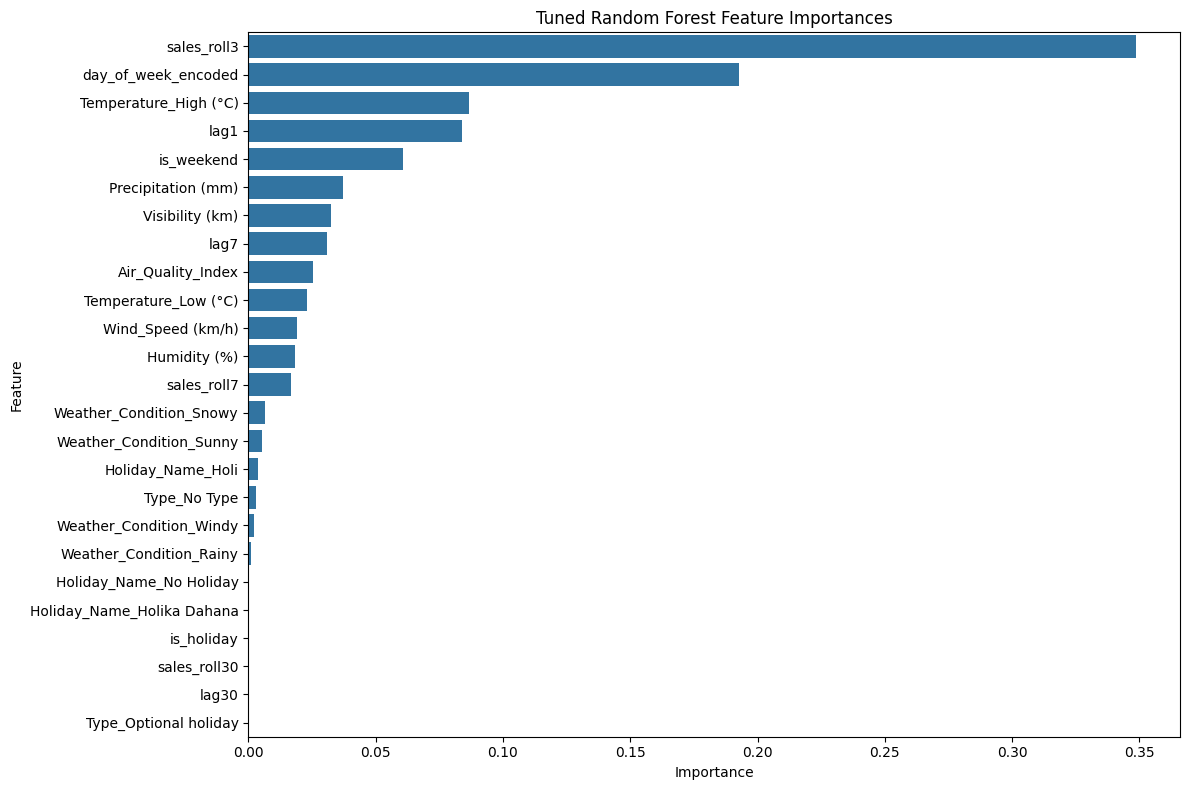

In [331]:
# Get feature importances from the tuned Random Forest model
rf_feature_importances = pd.DataFrame({
    'Feature': X_train_rf.columns,
    'Importance': tuned_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_feature_importances)
plt.title('Tuned Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Summary of Feature Importances for Sales Forecasting Models

XGBoost Model Feature Importances

sales_roll3: The 3-day rolling average of sales emerged as the single most important predictor, indicating that recent sales trends are highly indicative of future sales.


day_of_week_encoded: The day of the week (encoded numerically) is a strong factor, suggesting consistent weekly patterns in sales.


Sales: from the same day of the previous week are also highly relevant, capturing weekly seasonality.


lag30: Sales from the same day of the previous month contribute significantly, highlighting monthly patterns.


Temperature_High (°C): High temperatures have a notable impact on sales, suggesting weather conditions are influential.


sales roll7:The 7-day rolling average further reinforces the importance of recent sales performance.

XGBoost emphasizes the power of recent historical sales data (lagged features and rolling averages) and cyclical patterns (day of week, weekly/monthly seasonality) as primary drivers of sales.

Tuned Random Forest Model Feature Importances

**sales_roll3:** Again, the 3-day rolling average of sales is the most dominant feature, underscoring its predictive power.


**day_of_week_encoded:** The encoded day of the week is consistently a top predictor, confirming strong weekly sales cycles.


**Temperature_High (°C):** High temperatures are identified as a key external factor influencing sales.


**lag1:** Sales from the immediate previous day are also highly important.


**is_weekend:** Whether the day falls on a weekend or weekday significantly impacts sales.


Wind_Speed (km/h):  Wind speed also plays a role, indicating that various weather conditions affect customer behavior.

**Overall Conclusion for Stakeholders** :
Both models agree that recent sales trends (sales_roll3) and the day of the week (day_of_week_encoded) are the most crucial factors in predicting restaurant sales. Seasonal patterns (weekly, monthly) and specific weather conditions (high temperature, wind speed) also hold significant predictive value. Understanding these drivers allows for more informed strategies regarding staffing, inventory, marketing, and operational planning based on historical performance and predictable external factors.